## Mount Drive & copy images

In [1]:
from google.colab import drive
drive.mount('/content/drive')

!cp -r /content/drive/MyDrive/mini_proj_data/images /content/images


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
cp: cannot stat '/content/drive/MyDrive/mini_proj_data/images': No such file or directory


## Load CSV, prepare metadata, labels, splits

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from tensorflow.keras.utils import to_categorical
import os

df = pd.read_csv('/content/drive/MyDrive/mini_proj_data/processed_data.csv')
df = df[['image_path','clean_path','age','sex','localization','dx','dx_type']].copy()

df['age'] = pd.to_numeric(df['age'], errors='coerce')
df['age'] = df['age'].fillna(df['age'].median())
df['sex'] = df['sex'].str.lower().replace({'nan': np.nan, 'unknown': np.nan, '': np.nan})
df['sex'] = df['sex'].map({'male':0,'female':1})
df['sex'] = df['sex'].fillna(-1).astype('float32')

df = df.dropna(subset=['clean_path','dx'])
for col in ['localization','dx_type']:
    df[col] = df[col].fillna('unknown')
df = pd.get_dummies(df, columns=['localization','dx_type'], drop_first=False)

scaler = StandardScaler()
df['age_scaled'] = scaler.fit_transform(df[['age']]).astype('float32')

feature_cols = ['age_scaled','sex'] + [c for c in df.columns if c.startswith('localization_') or c.startswith('dx_type_')]
X_meta_all = df[feature_cols].values.astype('float32')

label_encoder = LabelEncoder()
y_all = label_encoder.fit_transform(df['dx'])
class_names = label_encoder.classes_
num_classes = len(class_names)
y_all_cat = to_categorical(y_all, num_classes=num_classes).astype('float32')

def map_to_local(path):
    return str(path).replace('/content/drive/MyDrive/mini_proj_data/images', '/content/images')

image_paths_all = df['clean_path'].astype(str).apply(map_to_local).values
missing = [p for p in image_paths_all if not os.path.exists(p)]
if len(missing) > 0:
    keep_mask = np.array([p not in missing for p in image_paths_all])
    image_paths_all = image_paths_all[keep_mask]
    X_meta_all = X_meta_all[keep_mask]
    y_all_cat = y_all_cat[keep_mask]
    y_all = y_all[keep_mask]

train_idx, temp_idx = train_test_split(np.arange(len(y_all)), test_size=0.3, stratify=y_all, random_state=42)
val_idx, test_idx   = train_test_split(temp_idx, test_size=0.5, stratify=y_all[temp_idx], random_state=42)

train_paths, val_paths, test_paths = image_paths_all[train_idx], image_paths_all[val_idx], image_paths_all[test_idx]
train_meta,  val_meta,  test_meta  = X_meta_all[train_idx], X_meta_all[val_idx], X_meta_all[test_idx]
train_labels, val_labels, test_labels = y_all_cat[train_idx], y_all_cat[val_idx], y_all_cat[test_idx]

chosen_loss = 'categorical_crossentropy'
print(f"Dataset sizes: train={len(train_paths)}, val={len(val_paths)}, test={len(test_paths)}, num_classes={num_classes}")


Dataset sizes: train=8236, val=1765, test=1766, num_classes=7


## tf.data pipelines

In [3]:
import tensorflow as tf

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

def load_and_preprocess(path):
    image = tf.io.read_file(path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32) / 255.0
    return tf.clip_by_value(image, 0.0, 1.0)

def preprocess_meta(meta):
    meta = tf.cast(meta, tf.float32)
    return tf.clip_by_value(meta, -5.0, 5.0)

ds_train_imgs = tf.data.Dataset.from_tensor_slices(train_paths).map(load_and_preprocess, num_parallel_calls=AUTOTUNE)
ds_val_imgs   = tf.data.Dataset.from_tensor_slices(val_paths).map(load_and_preprocess, num_parallel_calls=AUTOTUNE)
ds_test_imgs  = tf.data.Dataset.from_tensor_slices(test_paths).map(load_and_preprocess, num_parallel_calls=AUTOTUNE)

ds_train_meta = tf.data.Dataset.from_tensor_slices(train_meta.astype('float32')).map(preprocess_meta)
ds_val_meta   = tf.data.Dataset.from_tensor_slices(val_meta.astype('float32')).map(preprocess_meta)
ds_test_meta  = tf.data.Dataset.from_tensor_slices(test_meta.astype('float32')).map(preprocess_meta)

ds_train_lab = tf.data.Dataset.from_tensor_slices(train_labels.astype('float32'))
ds_val_lab   = tf.data.Dataset.from_tensor_slices(val_labels.astype('float32'))
ds_test_lab  = tf.data.Dataset.from_tensor_slices(test_labels.astype('float32'))

train_ds = tf.data.Dataset.zip(((ds_train_imgs, ds_train_meta), ds_train_lab)).shuffle(1000).batch(BATCH_SIZE).prefetch(AUTOTUNE)
val_ds   = tf.data.Dataset.zip(((ds_val_imgs, ds_val_meta), ds_val_lab)).cache().batch(BATCH_SIZE).prefetch(AUTOTUNE)
test_ds  = tf.data.Dataset.zip(((ds_test_imgs, ds_test_meta), ds_test_lab)).batch(BATCH_SIZE).prefetch(AUTOTUNE)


## Dual-Branch CNN (EfficientNetB0 + MobileNetV2)

In [4]:
# (Data loading and tf.data pipeline are unchanged, see above)

# Modified: Build model with two pretrained CNN branches + metadata
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import EfficientNetB0, MobileNetV2

image_input = layers.Input(shape=(*IMG_SIZE,3), name="image_input", dtype=tf.float32)
meta_input  = layers.Input(shape=(train_meta.shape[1],), name="metadata_input", dtype=tf.float32)

# Branch 1: EfficientNetB0
base1 = EfficientNetB0(include_top=False, weights='imagenet', input_shape=(*IMG_SIZE,3))
base1.trainable = False
x1 = base1(image_input)
x1 = layers.GlobalAveragePooling2D()(x1)

# Branch 2: MobileNetV2
base2 = MobileNetV2(include_top=False, weights='imagenet', input_shape=(*IMG_SIZE,3))
base2.trainable = False
x2 = base2(image_input)
x2 = layers.GlobalAveragePooling2D()(x2)

# Concatenate both feature vectors and metadata
fusion = layers.Concatenate()([x1, x2, meta_input])
x = layers.Dense(256, activation="relu")(fusion)
x = layers.Dropout(0.2)(x)
x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.2)(x)
x = layers.Dense(64,  activation="relu")(x)
x = layers.Dropout(0.2)(x)
output = layers.Dense(num_classes, activation="softmax")(x)

model = Model(inputs=[image_input, meta_input], outputs=output)

# Unchanged: Compile, train, and evaluate
from tensorflow.keras import optimizers, callbacks
opt = optimizers.Adam(learning_rate=1e-4, clipnorm=1.0)
model.compile(optimizer=opt, loss='categorical_crossentropy', metrics=["accuracy"])

cb = [
    callbacks.EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True),
    callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.3, patience=5, min_lr=1e-6)
]
history = model.fit(train_ds, validation_data=val_ds, epochs=20, callbacks=cb, verbose=1)


Epoch 1/20
258/258 ━━━━━━━━━━━━━━━━━━━━ 132s 339ms/step - accuracy: 0.5405 - loss: 1.3868 - val_accuracy: 0.6912 - val_loss: 0.9316 - learning_rate: 1.0000e-04
Epoch 2/20
258/258 ━━━━━━━━━━━━━━━━━━━━ 56s 109ms/step - accuracy: 0.6732 - loss: 0.9845 - val_accuracy: 0.7105 - val_loss: 0.8352 - learning_rate: 1.0000e-04
Epoch 3/20
258/258 ━━━━━━━━━━━━━━━━━━━━ 41s 111ms/step - accuracy: 0.7011 - loss: 0.8860 - val_accuracy: 0.7258 - val_loss: 0.7769 - learning_rate: 1.0000e-04
Epoch 4/20
258/258 ━━━━━━━━━━━━━━━━━━━━ 42s 116ms/step - accuracy: 0.7344 - loss: 0.7865 - val_accuracy: 0.7518 - val_loss: 0.7181 - learning_rate: 1.0000e-04
Epoch 5/20
258/258 ━━━━━━━━━━━━━━━━━━━━ 31s 112ms/step - accuracy: 0.7402 - loss: 0.7407 - val_accuracy: 0.7575 - val_loss: 0.6850 - learning_rate: 1.0000e-04
Epoch 6/20
258/258 ━━━━━━━━━━━━━━━━━━━━ 31s 109ms/step - accuracy: 0.7512 - loss: 0.7026 - val_accuracy: 0.7575 - val_loss: 0.6664 - learning_rate: 1.0000e-04
Epoch 7/20
258/258 ━━━━━━━━━━━━━━━━━━━━ 33s 1

## Evaluate

56/56 ━━━━━━━━━━━━━━━━━━━━ 23s 420ms/step - accuracy: 0.8119 - loss: 0.5259
Test results: [0.5263928174972534, 0.8165345191955566]
56/56 ━━━━━━━━━━━━━━━━━━━━ 27s 285ms/step
              precision    recall  f1-score   support

       akiec     0.8641    0.8071    0.8346       197
         bcc     0.4933    0.4805    0.4868        77
         bkl     0.5771    0.6121    0.5941       165
          df     0.7606    0.7826    0.7714        69
         mel     0.5325    0.4910    0.5109       167
          nv     0.9110    0.9264    0.9187      1006
        vasc     0.9167    0.9059    0.9112        85

    accuracy                         0.8165      1766
   macro avg     0.7222    0.7151    0.7183      1766
weighted avg     0.8150    0.8165    0.8155      1766

[[159   8  14   5   7   4   0]
 [  7  37  13   0   5  14   1]
 [  2  10 101   1  23  24   4]
 [  7   1   1  54   0   6   0]
 [  8   5  30   2  82  40   0]
 [  1  12  16   6  37 932   2]
 [  0   2   0   3   0   3  77]]


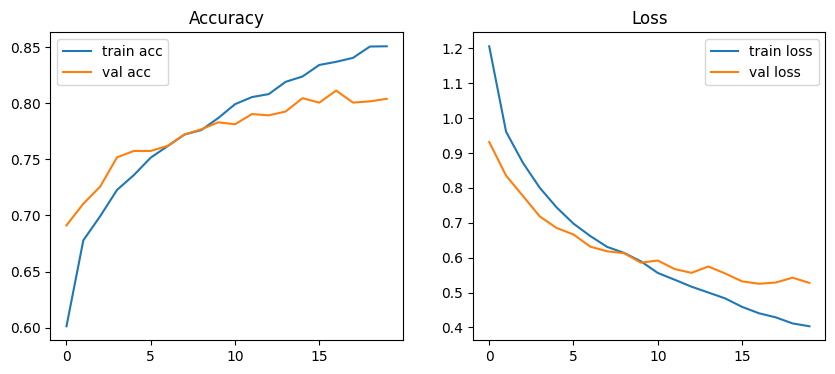

In [5]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

# Evaluate
results = model.evaluate(test_ds)
print("Test results:", results)

# Predictions
y_pred_probs = model.predict(test_ds)
y_pred = np.argmax(y_pred_probs, axis=1)

# Extract y_true
y_true_batches = []
for _, lbls in test_ds:
    y_true_batches.append(np.argmax(lbls.numpy(), axis=1))
y_true = np.concatenate(y_true_batches, axis=0)

# Reports
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))
print(confusion_matrix(y_true, y_pred))

# Plot training curves
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(history.history.get('accuracy', []), label='train acc')
plt.plot(history.history.get('val_accuracy', []), label='val acc')
plt.legend(); plt.title('Accuracy')

plt.subplot(1,2,2)
plt.plot(history.history.get('loss', []), label='train loss')
plt.plot(history.history.get('val_loss', []), label='val loss')
plt.legend(); plt.title('Loss')
plt.show()

# Save model (Keras format is recommended over H5)
model.save("custom_cnn_metadata_model.keras")
